# kordoc 이용해서 텍스트 추출

## 실행 전 환경 세팅

터미널에서 아래 순서대로 실행하세요.

```bash
uv sync --group notebook
nvm use 20
npm install
npx kordoc --help
```

확인할 것:
- `uv sync --group notebook`: 노트북 실행용 Python 패키지 설치
- `nvm use 20`: Node.js 20 사용
- `npm install`: `kordoc` 설치
- `npx kordoc --help`: `kordoc` 정상 실행 확인

그다음 VS Code나 Jupyter에서 이 프로젝트의 `.venv` 커널을 선택한 뒤 위에서부터 셀을 실행하면 됩니다.

processed 폴더에 parsed폴더 따로 생성되게 했음

raw 폴더는 data안에 따로 만들어야함

제 의식의 흐름대로 EDA한거라 지저분할 수 있습니다. 정리 못했습니다..

In [ ]:
import os
import re
import shlex

import platform
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import subprocess

from collections import Counter
from pathlib import Path

# 파싱 전

In [20]:
# 파일 경로 정리 (꼭 실행)
ROOT_DIR = Path.cwd().resolve()
while not (ROOT_DIR / "pyproject.toml").exists() and ROOT_DIR != ROOT_DIR.parent:
    ROOT_DIR = ROOT_DIR.parent

METADATA_PATH = ROOT_DIR / "data" / "raw" / "metadata" / "data_list.csv"
DATA_DIR = ROOT_DIR / "data" / "raw"
OUT_DIR = ROOT_DIR / "data" / "processed" / "parsed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 확인
assert ROOT_DIR.exists()
assert METADATA_PATH.exists()
assert DATA_DIR.exists()
assert OUT_DIR.exists()
metadata_df = pd.read_csv(METADATA_PATH)
assert not metadata_df.empty

print("경로 연결 정상")

경로 연결 정상


In [21]:
metadata_df.head()

,공고 번호,공고 차수,사업명,사업 금액,발주 기관,공개 일자,입찰 참여 시작일,입찰 참여 마감일,사업 요약,파일형식,파일명,텍스트
0,20241001798,0.0,한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화,130000000.0,한영대학,2024-10-04 13:51:23,NaN,2024-10-15 17:00:00,- 한영대학교 특성화 맞춤형 교육환경 구축을 위해 트랙운영 학사정보시스템을 고도화한...,hwp,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp,\n \n2024년 특성화 맞춤형 교육환경 구축 – 트랙운영 학사정보시스템 ...
1,20241002912,0.0,2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선,129300000.0,한국연구재단,2024-10-04 15:01:52,2024-10-14 10:00:00,2024-10-16 14:00:00,- 사업 개요: 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선\n...,hwp,한국연구재단_2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선.hwp,\r\n \r\n \r\n \r\n제 안 요 청 서\r\n[ 2024년 대학 ...
2,20240827859,0.0,EIP3.0 고압가스 안전관리 시스템 구축 용역,40000000.0,한국생산기술연구원,2024-08-28 11:31:02,2024-08-29 09:00:00,2024-09-09 10:00:00,- 사업 개요: EIP3.0 고압가스 안전관리 시스템 구축 용역\n- 추진배경: 안...,hwp,한국생산기술연구원_EIP3.0 고압가스 안전관리 시스템 구축 용역.hwp,\r\n \r\nEIP3.0 고압가스 안전관리\r\n시스템 구축 용역\...
3,20240430918,0.0,도시계획위원회 통합관리시스템 구축용역,150000000.0,인천광역시,2024-04-18 16:26:32,2024-05-02 10:00:00,2024-05-09 16:00:00,- 사업명: 도시계획위원회 통합관리시스템 구축 용역\n- 용역개요: 도시계획위원회와...,hwp,인천광역시_도시계획위원회 통합관리시스템 구축용역.hwp,\r\n \r\n \r\n도시계획위원회 통합관리시스템 구축\r\n제 안 요 청...
4,20240430896,0.0,봉화군 재난통합관리시스템 고도화 사업(협상)(긴급),900000000.0,경상북도 봉화군,2024-04-18 16:33:28,2024-04-26 09:00:00,2024-04-30 17:00:00,- 사업명: 봉화군 재난통합관리시스템 고도화 사업\n- 사업개요: 공동수급(공동이행...,hwp,경상북도 봉화군_봉화군 재난통합관리시스템 고도화 사업(협상)(긴급).hwp,\r\n \r\n \r\n제안요청서\r\n \r\n사 업 명\r\n봉화...


In [3]:
# 기본 통계 요약
metadata_df.shape
# 100개 문서, 12개 컬럼

(100, 12)

In [4]:
# 컬럼 확인
metadata_df.columns

Index(['공고 번호', '공고 차수', '사업명', '사업 금액', '발주 기관', '공개 일자', '입찰 참여 시작일',
       '입찰 참여 마감일', '사업 요약', '파일형식', '파일명', '텍스트'],
      dtype='str')

In [5]:
# 컬럼별 nan 수
print("=== 컬럼별 NaN 수 ===")
print(metadata_df.isnull().sum())
print()
print("=== 전체 shape ===")
print(metadata_df.shape)


=== 컬럼별 NaN 수 ===
공고 번호        18
공고 차수        18
사업명           0
사업 금액         1
발주 기관         0
공개 일자         0
입찰 참여 시작일    26
입찰 참여 마감일     8
사업 요약         0
파일형식          0
파일명           0
텍스트           0
dtype: int64

=== 전체 shape ===
(100, 12)


In [6]:
# 사업 금액이 NaN인 행
df[df["사업 금액"].isnull()]

,공고 번호,공고 차수,사업명,사업 금액,발주 기관,공개 일자,입찰 참여 시작일,입찰 참여 마감일,사업 요약,파일형식,파일명,텍스트
59,20240605351,0.0,기업 재생에너지 지원센터 홈페이지 개편 및 시스템 고도화 사업,NaN,대한상공회의소,2024-06-05 11:12:09,NaN,2024-06-14 14:00:00,- 기업 재생에너지 지원센터 홈페이지 개편 및 시스템 고도화 사업\n- 재생에너지 ...,hwp,대한상공회의소_기업 재생에너지 지원센터 홈페이지 개편 및 시스템 고.hwp,\r\n\t신 - \t\r\n \r\n \r\n기업 재생에너지 지원센터 ...


## pdf / hwp 전부 일관 변환 -> .mb 마크다운 형식으  (텍스트 추출) 

In [16]:
# .hwp 또는 .pdf로 끝나는 파일만 골라서 리스트로 만듦
files = [f for f in os.listdir(DATA_DIR) if f.endswith((".hwp", ".pdf"))]

# 변환 결과 추적용
ok_count = 0
fail_list = []

for i, fname in enumerate(files):
    # 상대경로를 절대경로로 변환 (kordoc이 절대경로를 필요로 함)
    input_path = os.path.abspath(os.path.join(DATA_DIR, fname))
    # 확장자를 .md로 바꿔서 출력 파일명 생성 (예: 벤처기업.hwp → 벤처기업.md)
    output_name = os.path.splitext(fname)[0] + ".md"
    # 출력 폴더 + 출력 파일명 합쳐서 저장 경로 생성
    output_path = os.path.join(OUT_DIR, output_name)

    # npx kordoc 명령어를 실행하여 hwp/pdf → md 변환
    kordoc_cmd = (
        'export NVM_DIR="$HOME/.nvm" && '
        '[ -s "$NVM_DIR/nvm.sh" ] && . "$NVM_DIR/nvm.sh" && '
        'nvm use 20 >/dev/null && '
        f"npx kordoc {shlex.quote(input_path)} -o {shlex.quote(output_path)}"
    )
    result = subprocess.run(
        ["bash", "-lc", kordoc_cmd],
        capture_output=True,
        encoding="utf-8",
        errors="replace"
    )

    # 성공/실패 기록
    if result.returncode == 0:
        ok_count += 1
    else:
        fail_list.append(fname)

    # 진행 상황 출력 (예: [1/100] OK - 벤처기업.hwp)
    status = "OK" if result.returncode == 0 else "FAIL"
    print(f"[{i+1}/{len(files)}] {status} - {fname}")

# 최종 요약
print(f"\n{'='*40}")
print(f"성공: {ok_count}/{len(files)}")
print(f"실패: {len(fail_list)}개")
if fail_list:
    print("실패 파일:")
    for f in fail_list:
        print(f"  - {f}")

[1/100] OK - 한국생산기술연구원_2세대 전자조달시스템  기반구축사업.hwp
[2/100] OK - 한국원자력연구원_한국원자력연구원 선량평가시스템 고도화.hwp
[3/100] OK - 한국수자원공사_건설통합시스템(CMS) 고도화.hwp
[4/100] OK - 한국농어촌공사_아세안+3 식량안보정보시스템(AFSIS) 3단계 협력(캄보디아.hwp
[5/100] OK - 인천광역시 동구_수도국산달동네박물관 전시해설 시스템 구축(협상에 .hwp
[6/100] OK - 한국사학진흥재단_대학재정정보시스템(기본재산 및 기채 사후관리) 고.hwp
[7/100] OK - 수협중앙회_강릉어선안전조업국 상황관제시스템 구축.hwp
[8/100] OK - 한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp
[9/100] OK - 대한상공회의소_기업 재생에너지 지원센터 홈페이지 개편 및 시스템 고.hwp
[10/100] OK - 한국철도공사 (용역)_모바일오피스 시스템 고도화 용역(총체 및 1차).hwp
[11/100] OK - 한국수자원공사_용인 첨단 시스템반도체 국가산단 용수공급사업 타당성.hwp
[12/100] OK - 국민연금공단_사업장 사회보험료 지원 고시 개정에 따른 정보시스템 보.hwp
[13/100] OK - 한국보육진흥원_연차별 자율 품질관리 시스템 기능개선.hwp
[14/100] OK - 한국철도공사 (용역)_예약발매시스템 개량 ISMP 용역.hwp
[15/100] OK - 광주과학기술원_실시간통합연구비관리시스템(RCMS)  연계 모듈 변경 사업.hwp
[16/100] OK - 재단법인스포츠윤리센터_스포츠윤리센터 LMS(학습지원시스템) 기능개선.hwp
[17/100] OK - 조선대학교_(재공고)2024 조선대학교 SW중심대학 사업관리시스템(WeHub) 구.hwp
[18/100] OK - 한국수자원조사기술원_수문자료정보관리시스템(HDIMS) 재구축 용역(3단계.hwp
[19/100] OK - 재단법인 한국장애인문화예술원_2024년 장애인

In [29]:
# 확인
parsed_files = sorted(OUT_DIR.glob("*.md"))
source_files = sorted([p for p in DATA_DIR.iterdir() if p.suffix.lower() in {".hwp", ".pdf"}])

print(f"원본 파일 수: {len(source_files)}")
print(f"변환된 md 파일 수: {len(parsed_files)}")

empty_files = [p.name for p in parsed_files if p.stat().st_size == 0]
print(f"빈 md 파일 수: {len(empty_files)}")
if empty_files:
    print("빈 파일:")
    for name in empty_files[:10]:
        print(f"  - {name}")

parsed_names = {p.stem for p in parsed_files}
source_names = {p.stem for p in source_files}

missing_outputs = sorted(source_names - parsed_names)
extra_outputs = sorted(parsed_names - source_names)

print(f"\n변환 안 된 파일 수: {len(missing_outputs)}")
if missing_outputs:
    for name in missing_outputs[:10]:
        print(f"  - {name}")

print(f"\n원본에는 없는데 parsed에만 있는 파일 수: {len(extra_outputs)}")
if extra_outputs:
    for name in extra_outputs[:10]:
        print(f"  - {name}")

원본 파일 수: 100
변환된 md 파일 수: 100
빈 md 파일 수: 0

변환 안 된 파일 수: 0

원본에는 없는데 parsed에만 있는 파일 수: 0


-> 눈으로 확인 --> 문단 구조랑 표 잘 추출된거 같음

# docx -> 추출

uv add python-docx

uv add markitdown

uv add "markitdown[docx]"

이 부분은 필요 없음 넘어가기

# csv에 있는 파일목록만 사용

docx 필요없음

In [22]:
# csv에 있는 파일 목록
print(f"CSV 파일 수: {len(metadata_df)}")
print(metadata_df.columns.tolist())  # 컬럼명 확인

CSV 파일 수: 100
['공고 번호', '공고 차수', '사업명', '사업 금액', '발주 기관', '공개 일자', '입찰 참여 시작일', '입찰 참여 마감일', '사업 요약', '파일형식', '파일명', '텍스트']


In [23]:
# 실제 원본 파일 목록
actual_files = [f for f in os.listdir(DATA_DIR) if f.endswith((".hwp", ".pdf", ".docx"))]
print(f"실제 파일 수: {len(actual_files)}")

실제 파일 수: 100


In [24]:
# 파일명 컬럼 기준으로 비교
actual_files = [f for f in os.listdir(DATA_DIR) if f.endswith((".hwp", ".pdf", ".docx"))]
csv_files = metadata_df["파일명"].tolist()

missing = [f for f in actual_files if f not in csv_files]
print(f"CSV에 없는 파일:")
for f in missing:
    print(f"  - {f}")

CSV에 없는 파일:


# EDA

In [ ]:
# 한글 폰트 찾기
candidate_fonts = []

if platform.system() == "Windows":
    candidate_fonts = ["Malgun Gothic", "AppleGothic", "NanumGothic"]
elif platform.system() == "Darwin":
    candidate_fonts = ["AppleGothic", "NanumGothic", "Malgun Gothic"]
else:
    candidate_fonts = ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR", "Malgun Gothic"]

available_fonts = {f.name for f in fm.fontManager.ttflist}

selected_font = None
for font in candidate_fonts:
    if font in available_fonts:
        selected_font = font
        break

if selected_font is not None:
    plt.rcParams["font.family"] = selected_font
    print(f"사용 폰트: {selected_font}")
else:
    print("사용 가능한 한글 폰트를 찾지 못했습니다.")

plt.rcParams["axes.unicode_minus"] = False

사용 가능한 한글 폰트를 찾지 못했습니다.


In [34]:
# 제발 모든 환경에서 맞아야 한다..
if platform.system() == "Windows":
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == "Darwin":
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [26]:
# 각 파일 길이 확인
data = []
for fname in os.listdir(OUT_DIR):
    if not fname.endswith(".md"):
        continue
    path = os.path.join(OUT_DIR, fname)
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    data.append({
        "파일명": fname,
        "글자수": len(text),
        "라인수": len(text.splitlines()),
    })

df = pd.DataFrame(data).sort_values("글자수", ascending=False).reset_index(drop=True)
print(f"총 문서 수: {len(df)}")
df.describe()



총 문서 수: 100


,글자수,라인수
count,100.000000,100.000000
mean,92880.530000,1626.110000
std,32919.488936,569.097742
min,47774.000000,605.000000
25%,71695.750000,1270.500000
50%,84308.000000,1490.000000
75%,103558.000000,1799.000000
max,245619.000000,4152.000000


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
/tmp/ipykernel_105951/2276978140.py:8: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_105951/2276978140.py:8: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_105951/2276978140.py:8: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_105951/2276978140.py:8: UserWarning: Glyph 45937 (\N{HANGUL SYLLABLE DEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_105951/2276978140.py:8: UserWarn

/tmp/ipykernel_105951/2276978140.py:8: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_105951/2276978140.py:8: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
/home/user2/workspace/pjt-sprint_ai07_bidmateRAG/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44544 (\N{HANGUL SYLLABLE GEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/user2/workspace/pjt-sprint_ai07_bidmateRAG/.venv/lib/python3.12/site-packages/IP

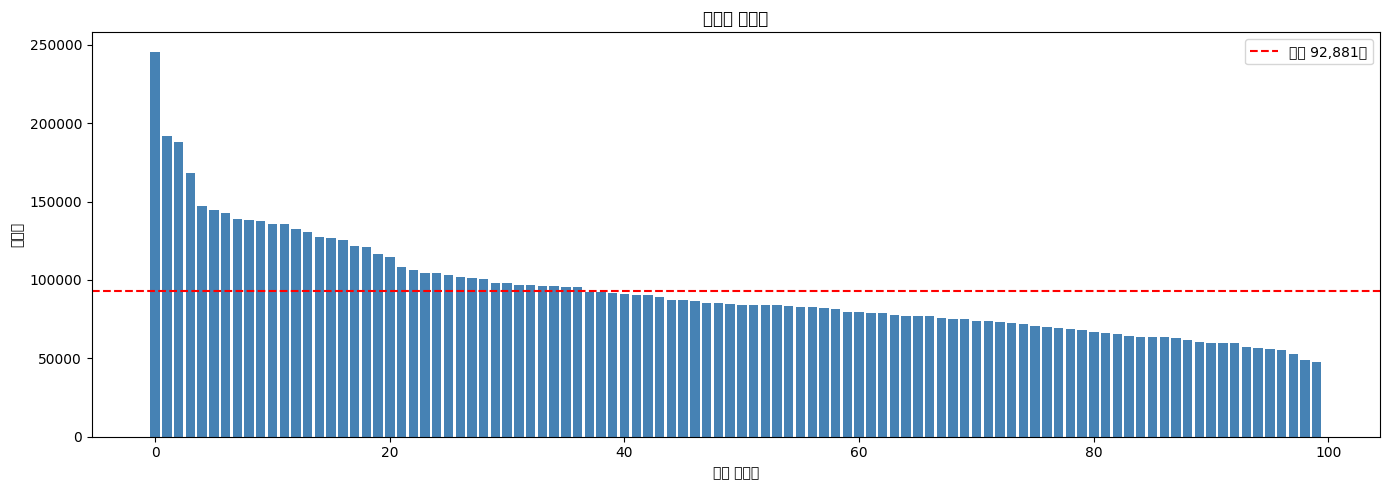

In [27]:
plt.figure(figsize=(14, 5))
plt.bar(range(len(df)), df["글자수"], color="steelblue")
plt.title("파일별 글자수")
plt.xlabel("파일 인덱스")
plt.ylabel("글자수")
plt.axhline(df["글자수"].mean(), color="red", linestyle="--", label=f"평균 {df['글자수'].mean():,.0f}자")
plt.legend()
plt.tight_layout()
plt.show()

## 문서 확인 

In [35]:
# 1. 짧은 문서 확인
short_docs = df[df["글자수"] < 50000]
print(f"글자수 50000 미만 문서: {len(short_docs)}개")
if len(short_docs) > 0:
    print(short_docs[["파일명", "글자수"]])

글자수 50000 미만 문서: 2개
                                                 파일명    글자수
98  조선대학교_(재공고)2024 조선대학교 SW중심대학 사업관리시스템(WeHub) 구.md  48993
99           한국수자원공사_용인 첨단 시스템반도체 국가산단 용수공급사업 타당성.md  47774


In [36]:
# 2. 중복 문서 확인 (글자수가 완전히 같은 경우)
dup_docs = df[df.duplicated(subset=["글자수"], keep=False)]
print(f"글자수 동일 문서: {len(dup_docs)}개")
if len(dup_docs) > 0:
    print(dup_docs[["파일명", "글자수"]].sort_values("글자수"))

글자수 동일 문서: 4개
                                            파일명    글자수
60              국가과학기술지식정보서비스_통합정보시스템 고도화 용역.md  79323
59                   한국한의학연구원_통합정보시스템 고도화 용역.md  79323
38       한국보건산업진흥원_의료기기산업 종합정보시스템(정보관리기관) 기능.md  92181
37  BioIN_의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업(2차).md  92181


In [37]:
# 두 파일 내용 비교
fname1 = "한국한의학연구원_통합정보시스템 고도화 용역.md"
fname2 = "국가과학기술지식정보서비스_통합정보시스템 고도화 용역.md"

with open(os.path.join(OUT_DIR, fname1), "r", encoding="utf-8") as f:
    text1 = f.read()
with open(os.path.join(OUT_DIR, fname2), "r", encoding="utf-8") as f:
    text2 = f.read()

print(f"{fname1}: {len(text1):,}자")
print(f"{fname2}: {len(text2):,}자")
print(f"완전히 동일: {text1 == text2}")

한국한의학연구원_통합정보시스템 고도화 용역.md: 79,323자
국가과학기술지식정보서비스_통합정보시스템 고도화 용역.md: 79,323자
완전히 동일: True


In [17]:
targets = [
    "한국한의학연구원_통합정보시스템 고도화 용역.hwp",
    "국가과학기술지식정보서비스_통합정보시스템 고도화 용역.hwp",
    "한국보건산업진흥원_의료기기산업 종합정보시스템(정보관리기관) 기능.hwp",
    "BioIN_의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업(2차).hwp"
]

metadata_df[metadata_df["파일명"].isin(targets)]



,공고 번호,공고 차수,사업명,사업 금액,발주 기관,공개 일자,입찰 참여 시작일,입찰 참여 마감일,사업 요약,파일형식,파일명,텍스트
15,NaN,NaN,통합정보시스템 고도화 용역,140000000.0,국가과학기술지식정보서비스,2024-05-30 00:00:00,2024-05-30 00:00:00,2024-06-11 00:00:00,"- 사업 개요: 통합정보시스템 고도화 용역, 사업기간 5개월 이내, 추정가격 140...",hwp,국가과학기술지식정보서비스_통합정보시스템 고도화 용역.hwp,\r\n \r\n제안요청서\r\n \r\n 통합정보시스템 고도화 용역\r\n제...
21,20240904268,0.0,의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업,50000000.0,한국보건산업진흥원,2024-09-04 18:33:03,2024-09-13 10:00:00,2024-09-20 10:00:00,- 사업개요: 의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업(올인원 플랫폼...,hwp,한국보건산업진흥원_의료기기산업 종합정보시스템(정보관리기관) 기능.hwp,\r\n제 안 요 청 서 \r\n \r\n사 업 명\r\n의료기기산업 종합정...
46,NaN,NaN,의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업(2차),50000000.0,BioIN,2024-09-05 00:00:00,NaN,NaN,- 사업명: 의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업(올인원 플랫폼 ...,hwp,BioIN_의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업(2차).hwp,\r\n제 안 요 청 서 \r\n \r\n사 업 명\r\n의료기기산업 종합정...
53,20240535775,0.0,통합정보시스템 고도화 용역,140000000.0,한국한의학연구원,2024-05-30 09:04:12,2024-05-30 10:00:00,2024-06-11 11:00:00,"- 사업 개요: 통합정보시스템 고도화 용역으로 기관생명윤리, 동물실험윤리, 국가연구...",hwp,한국한의학연구원_통합정보시스템 고도화 용역.hwp,\r\n \r\n제안요청서\r\n \r\n 통합정보시스템 고도화 용역\r\n제...


In [18]:
# 3. 특수문자/노이즈 확인
noise_pattern = re.compile(r'[^\w\s가-힣ㄱ-ㅎㅏ-ㅣ\.,\(\)\[\]\|·•□◦○※①②③\-\:]')

noise_data = []
for fname in os.listdir(OUT_DIR):
    if not fname.endswith(".md"):
        continue
    path = os.path.join(OUT_DIR, fname)
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    noise_chars = noise_pattern.findall(text)
    noise_data.append({
        "파일명": fname,
        "노이즈_수": len(noise_chars),
        "노이즈_샘플": list(set(noise_chars))[:10]
    })

df_noise = pd.DataFrame(noise_data).sort_values("노이즈_수", ascending=False).reset_index(drop=True)
print(f"노이즈 평균: {df_noise['노이즈_수'].mean():.0f}개")
df_noise.head(10)

노이즈 평균: 2539개


,파일명,노이즈_수,노이즈_샘플
0,고려대학교_차세대 포털·학사 정보시스템 구축사업.md,11655,"[☏, ◯, ★, ▶, ㎡, –, ÷, ’, 」, =]"
1,서울시립대학교_[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차.md,6910,"[』, ◯, ★, , ㎡, –, ∘, , §, ’]"
2,그랜드코리아레저(주)_2024년도 GKL 그룹웨어 시스템 구축 용역.md,6348,"[󰊶, ★, ▶, –, ◈, ‣, ’, ▲, 」, ․]"
3,한국가스공사_[재공고]차세대 통합정보시스템(ERP) 구축.md,5445,"[』, –, ’, 」, ․, &, 󰊳, +, ∼, ❍]"
4,울산광역시_2024년 버스정보시스템 확대 구축 및 기능개선 용역.md,4989,"[〔, 』, ☐, ↓, ㎡, ✕, （, ’, 」, ‵]"
5,서울특별시_2024년 지도정보 플랫폼 및 전문활용 연계 시스템 고도화 용.md,4608,"[』, %, ★, –, ∘, , §, ’, 」, =]"
6,"서울특별시 여성가족재단_(재공고, 협상) 서울 디지털성범죄 안심지원센.md",4066,"[』, %, ☏, 󰂙, ㎡, –, ∨, ∘, §, ’]"
7,(사)벤처기업협회_2024년 벤처확인종합관리시스템 기능 고도화 용역사업 .md,4004,"[』, ★, ㎡, ∨, ▫, ◈, ’, 」, =, ․]"
8,한국사학진흥재단_대학재정정보시스템(기본재산 및 기채 사후관리) 고.md,3850,"[▶, ㎡, ÷, ’, 」, ●, =, ․, &, ]"
9,KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .md,3768,"[%, ▶, ↓, ㎡, （, –, ∨, , ’, ▲]"


자동으로 확인하기 힘들다 .. 직접 보는게 맞음 ...아놔

In [ ]:
# 특수 문자 / 노이즈 앞뒤 문장 맥락 파악


In [11]:
# 별첨/양식 섹션 — 패턴 및 위치 EDA

# 탐지할 후보 패턴 (발견 목적 — 확정 아님)
APPENDIX_PATTERNS = [
    # 붙임
    r'\[붙임\s*\d*\]',
    r'^\s*붙임\s*\d+',
    r'## 붙임',
    # 별표
    r'\[별표\s*\d*\]',
    r'## \[별표',
    # 별지
    r'\[별지\s*\d*\]',
    r'^\s*별지\s*서식',
    r'## 별지',
    # 별첨
    r'\[별첨\s*\d*\]',
    r'^\s*별첨',
    # 서식 관련 (신규 추가)
    r'제안서\s*관련\s*서식',
    r'【별도서식】',
    r'\[서식\s*제?\s*\d+\s*호?\]',
    r'^\s*붙임\s*서식',
    r'^\s*서식\s*\d+',
    r'^\s*\[서식\]',
    r'별도\s*서식',
    r'서식\s*제\s*\d+\s*호',
    r'\[별지\s*제\s*\d+\s*호\s*서식?\]',
    r'별지\s*제\s*\d+\s*호\s*서식',
]
compiled = [(p, re.compile(p, re.MULTILINE)) for p in APPENDIX_PATTERNS]

rows = []
for fname in os.listdir(OUT_DIR):
    if not fname.endswith(".md"):
        continue
    path = os.path.join(OUT_DIR, fname)
    with open(path, encoding="utf-8") as f:
        text = f.read()
    total_len = len(text)

    hits = []
    for pattern_str, pattern in compiled:
        for m in pattern.finditer(text):
            hits.append({
                "패턴": pattern_str,
                "매칭텍스트": m.group()[:50],
                "위치_char": m.start(),
                "위치_%": round(m.start() / total_len * 100, 1),
            })

    rows.append({
        "파일명": fname,
        "총길이": total_len,
        "별첨_히트수": len(hits),
        "첫_별첨_위치_%": min((h["위치_%"] for h in hits), default=None),
        "발견_패턴목록": list({h["패턴"] for h in hits}),
        "히트_상세": hits,
    })

df_appendix = pd.DataFrame(rows).sort_values("첫_별첨_위치_%")

# 요약
print("=== 별첨/서식 패턴 발견 현황 ===")
print(f"전체 파일 수: {len(df_appendix)}")
print(f"패턴 있는 파일: {(df_appendix['별첨_히트수'] > 0).sum()}")
print(f"패턴 없는 파일: {(df_appendix['별첨_히트수'] == 0).sum()}")
print()

# 패턴별 등장 빈도
all_patterns = [p for row in df_appendix["발견_패턴목록"] for p in row]
print("=== 패턴별 등장 파일 수 ===")
print(pd.Series(Counter(all_patterns)).sort_values(ascending=False).to_string())
print()

# 첫 별첨 위치 분포
print("=== 첫 별첨/서식 시작 위치 분포 (%) ===")
print(df_appendix["첫_별첨_위치_%"].describe())


=== 별첨/서식 패턴 발견 현황 ===
전체 파일 수: 100
패턴 있는 파일: 100
패턴 없는 파일: 0

=== 패턴별 등장 파일 수 ===
별지\s*제\s*\d+\s*호\s*서식         65
\[붙임\s*\d*\]                  56
\[별표\s*\d*\]                  51
\[별지\s*제\s*\d+\s*호\s*서식?\]    43
\[서식\s*제?\s*\d+\s*호?\]        33
## \[별표                       33
\[별첨\s*\d*\]                  29
서식\s*제\s*\d+\s*호              26
별도\s*서식                       20
제안서\s*관련\s*서식                 20
\[별지\s*\d*\]                  19
^\s*별첨                         9
^\s*별지\s*서식                    8
^\s*붙임\s*\d+                   6
^\s*서식\s*\d+                   4
^\s*붙임\s*서식                    1
【별도서식】                         1

=== 첫 별첨/서식 시작 위치 분포 (%) ===
count    100.000000
mean      25.213000
std       27.399272
min        0.000000
25%        0.900000
50%       16.100000
75%       47.100000
max       90.100000
Name: 첫_별첨_위치_%, dtype: float64


In [25]:
# 별첨 없는 파일 — 별도로 확인 필요
print("=== 별첨 패턴 미발견 파일 ===")
no_appendix = df_appendix[df_appendix["별첨_히트수"] == 0]["파일명"].tolist()
for f in no_appendix[:10]:
    print(f)


=== 별첨 패턴 미발견 파일 ===
나노종합기술원_스마트 팹 서비스 활용체계 구축관련 설비온라인 시스.md
한국로봇산업진흥원_한국로봇산업진흥원 사업관리시스템 온라인평가 .md
한국수자원공사_용인 첨단 시스템반도체 국가산단 용수공급사업 타당성.md


In [13]:
# 특정 파일의 히트 상세 확인
sample_fname = [f for f in df_appendix["파일명"] if f.startswith("나노종합기술원")][0]
sample_hits = df_appendix[df_appendix["파일명"] == sample_fname]["히트_상세"].values[0]
print(f"=== {sample_fname} ===")
for h in sorted(sample_hits, key=lambda x: x["위치_%"]):
    print(f"  {h['위치_%']:5.1f}%  [{h['패턴']}]  →  {h['매칭텍스트']}")


=== 나노종합기술원_스마트 팹 서비스 활용체계 구축관련 설비온라인 시스.md ===
    9.4%  [별지\s*제\s*\d+\s*호\s*서식]  →  별지 제7호서식
    9.6%  [별지\s*제\s*\d+\s*호\s*서식]  →  별지 제4호서식


In [12]:
# 특정 파일의 히트 상세 확인 (의심 파일 골라서 보기)
sample_fname = df_appendix[df_appendix["별첨_히트수"] > 0].iloc[0]["파일명"]
sample_hits = df_appendix[df_appendix["파일명"] == sample_fname]["히트_상세"].values[0]
print(f"=== {sample_fname} ===")
for h in sample_hits:
    print(f"  {h['위치_%']:5.1f}%  [{h['패턴']}]  →  {h['매칭텍스트']}")

=== 축산물품질평가원_꿀 품질평가 전산시스템 기능개선 사업.md ===
    0.0%  [\[붙임\s*\d*\]]  →  [붙임]
   59.7%  [\[별표\s*\d*\]]  →  [별표19]
    1.4%  [\[별첨\s*\d*\]]  →  [별첨1]
    1.4%  [\[별첨\s*\d*\]]  →  [별첨2]
    1.4%  [\[별첨\s*\d*\]]  →  [별첨3]
    1.4%  [\[별첨\s*\d*\]]  →  [별첨4]
   95.9%  [\[별첨\s*\d*\]]  →  [별첨 1]
   95.9%  [\[별첨\s*\d*\]]  →  [별첨 2]
   96.0%  [\[별첨\s*\d*\]]  →  [별첨 3]
   96.2%  [\[별첨\s*\d*\]]  →  [별첨 1]
   96.3%  [\[별첨\s*\d*\]]  →  [별첨 2]
   96.3%  [\[별첨\s*\d*\]]  →  [별첨 3]
   96.3%  [\[별첨\s*\d*\]]  →  [별첨 4]
   96.3%  [\[별첨\s*\d*\]]  →  [별첨1]
   98.3%  [\[별첨\s*\d*\]]  →  [별첨2]
   98.6%  [\[별첨\s*\d*\]]  →  [별첨1]
   98.8%  [\[별첨\s*\d*\]]  →  [별첨3]
   99.2%  [\[별첨\s*\d*\]]  →  [별첨4]
    0.9%  [제안서\s*관련\s*서식]  →  제안서 관련 서식
   66.7%  [제안서\s*관련\s*서식]  →  제안서 관련 서식
    0.9%  [\[서식\s*제?\s*\d+\s*호?\]]  →  [서식1]
    0.9%  [\[서식\s*제?\s*\d+\s*호?\]]  →  [서식2]
    1.0%  [\[서식\s*제?\s*\d+\s*호?\]]  →  [서식3]
    1.0%  [\[서식\s*제?\s*\d+\s*호?\]]  →  [서식4]
    1.0%  [\[서식\s*제?\s*\d+\s*호?\]]  →  [서식5]
    1.0%  [\[서식\s

## 표 비중 확인 -> 청킹 전략 

In [22]:
# 표 비중 확인
data2 = []
for fname in os.listdir(OUT_DIR):
    if not fname.endswith(".md"):
        continue
    path = os.path.join(OUT_DIR, fname)
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    lines = text.splitlines()
    non_empty = [l for l in lines if l.strip()]
    table_lines = [l for l in lines if l.strip().startswith("|")]
    data2.append({
        "파일명": fname,
        "글자수": len(text),
        "표_라인수": len(table_lines),
        "전체_라인수": len(non_empty),
        "표_비중": len(table_lines) / len(non_empty) if non_empty else 0
    })

df2 = pd.DataFrame(data2).sort_values("표_비중", ascending=False).reset_index(drop=True)
print(f"표 비중 평균: {df2['표_비중'].mean()*100:.1f}%")
print(f"표 비중 0% 문서: {len(df2[df2['표_비중']==0])}개")
df2[["파일명", "글자수", "표_라인수", "전체_라인수", "표_비중"]].head(10)


표 비중 평균: 60.3%
표 비중 0% 문서: 0개


,파일명,글자수,표_라인수,전체_라인수,표_비중
0,한국가스공사_[재공고]차세대 통합정보시스템(ERP) 구축.md,125583,1237,1368,0.904240
1,나노종합기술원_스마트 팹 서비스 활용체계 구축관련 설비온라인 시스.md,83003,1058,1279,0.827209
2,인천공항운영서비스(주)_인천공항운영서비스㈜ 차세대 ERP시스템 구축 .md,72250,869,1102,0.788566
3,(사）한국대학스포츠협의회_KUSF 체육특기자 경기기록 관리시스템 개발.md,100609,1036,1358,0.762887
4,고려대학교_차세대 포털·학사 정보시스템 구축사업.md,245637,2385,3183,0.749293
5,한국발명진흥회 입찰공고_2024년 건설기술에 관한 특허·실용신안 활용실.md,75091,960,1282,0.748830
6,경기도사회서비스원_2024년 통합사회정보시스템 운영지원.md,98275,1164,1569,0.741874
7,(사)벤처기업협회_2024년 벤처확인종합관리시스템 기능 고도화 용역사업 .md,135714,1476,2012,0.733598
8,한국한의학연구원_통합정보시스템 고도화 용역.md,79323,914,1247,0.732959
9,국가과학기술지식정보서비스_통합정보시스템 고도화 용역.md,79323,914,1247,0.732959


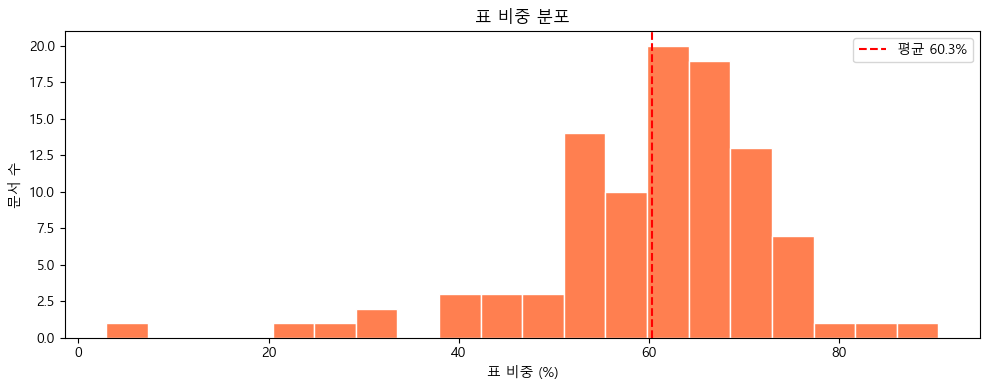

In [23]:
plt.figure(figsize=(10, 4))
plt.hist(df2["표_비중"] * 100, bins=20, color="coral", edgecolor="white")
plt.title("표 비중 분포")
plt.xlabel("표 비중 (%)")
plt.ylabel("문서 수")
plt.axvline(df2["표_비중"].mean() * 100, color="red", linestyle="--", label=f"평균 {df2['표_비중'].mean()*100:.1f}%")
plt.legend()
plt.tight_layout()
plt.show()

전체 표 수: 10,909개
평균 표 크기: 8.0줄
중앙값: 7줄
최대: 179줄
count    10909.000000
mean         8.035292
std          8.779776
min          1.000000
25%          4.000000
50%          7.000000
75%          8.000000
max        179.000000
dtype: float64


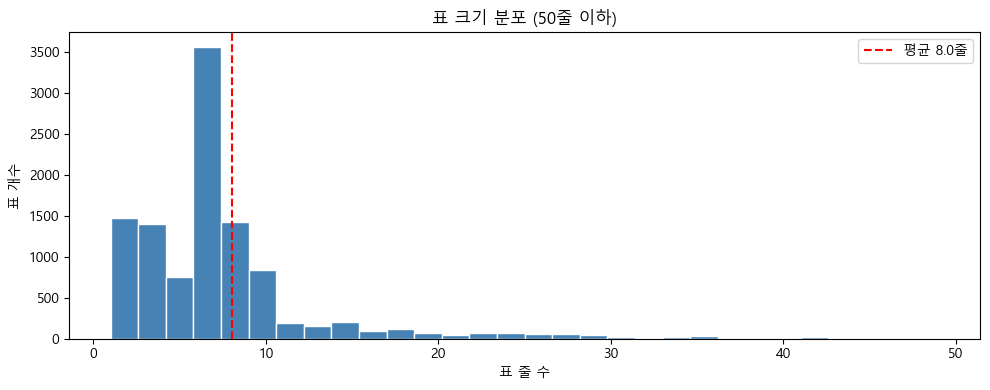

In [31]:
# 표 크기 분포 -> 표 하나당 몇 줄일까?
table_sizes = []  # 모든 표의 줄 수를 담을 리스트

for fname in os.listdir(OUT_DIR):
    if not fname.endswith(".md"):
        continue
    path = os.path.join(OUT_DIR, fname)
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    current_table = 0  # 현재 표의 줄 수 카운터
    for line in lines:
        if line.strip().startswith("|"):  # 표 라인인 경우
            current_table += 1
        else:
            if current_table > 0:  # 표가 끝난 경우 크기 저장
                table_sizes.append(current_table)
                current_table = 0  # 카운터 초기화
    if current_table > 0:  # 파일 끝에 표가 있는 경우
        table_sizes.append(current_table)

s_table = pd.Series(table_sizes)
print(f"전체 표 수: {len(s_table):,}개")
print(f"평균 표 크기: {s_table.mean():.1f}줄")
print(f"중앙값: {s_table.median():.0f}줄")
print(f"최대: {s_table.max()}줄")
print(s_table.describe())

# 표 크기 분포 시각화
# - 어느 크기의 표가 많은지 한눈에 파악
plt.figure(figsize=(10, 4))
plt.hist(s_table[s_table < 50], bins=30, color="steelblue", edgecolor="white")
plt.title("표 크기 분포 (50줄 이하)")
plt.xlabel("표 줄 수")
plt.ylabel("표 개수")
plt.axvline(s_table.mean(), color="red", linestyle="--", label=f"평균 {s_table.mean():.1f}줄")
plt.legend()
plt.tight_layout()
plt.show()

## 세션 구조 파악

1. 헤더 패턴

In [24]:
section_pattern = re.compile(
    r'^(Ⅰ|Ⅱ|Ⅲ|Ⅳ|Ⅴ|Ⅵ|Ⅶ|Ⅷ|Ⅸ|Ⅹ|\d+\.|제\d+장|제\d+절)',
    re.MULTILINE
)

section_data = []
for fname in os.listdir(OUT_DIR):
    if not fname.endswith(".md"):
        continue
    path = os.path.join(OUT_DIR, fname)
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    
    matches = section_pattern.findall(text)
    section_data.append({
        "파일명": fname,
        "섹션수": len(matches),
        "섹션패턴": matches[:10]  # 앞 10개만
    })

df3 = pd.DataFrame(section_data).sort_values("섹션수", ascending=False).reset_index(drop=True)
print(f"섹션수 평균: {df3['섹션수'].mean():.1f}")
print(f"섹션수 최소: {df3['섹션수'].min()} / 최대: {df3['섹션수'].max()}")
df3.head(10)

섹션수 평균: 71.2
섹션수 최소: 7 / 최대: 230


,파일명,섹션수,섹션패턴
0,대한상공회의소_기업 재생에너지 지원센터 홈페이지 개편 및 시스템 고.md,230,"[2024., Ⅰ, 1., 2., 3., 4., 5., 6., Ⅱ, 1.]"
1,한국철도공사 (용역)_예약발매시스템 개량 ISMP 용역.md,206,"[2024., 1., 2., 3., 4., 1., 2., 3., 1., 2.]"
2,기초과학연구원_2025년도 중이온가속기용 극저온시스템 운전 용역.md,174,"[1., 3., 5., 7., 8., 9., 1., 1., 1., 1.]"
3,경기도 평택시_2024년도 평택시 버스정보시스템(BIS) 구축사업.md,166,"[Ⅰ, 1., 1., 1., 1., 1., 1., 1., 1., 2.]"
4,"서울특별시 여성가족재단_(재공고, 협상) 서울 디지털성범죄 안심지원센.md",148,"[2024., Ⅰ, 1., 2., 3., 4., Ⅱ, 1., 2., 3.]"
5,수협중앙회_수협중앙회 수산물사이버직매장 시스템 재구축 ISMP 수립 입.md,147,"[2024., Ⅰ, 1., 2., 3., 4., 5., Ⅱ, Ⅲ, 1.]"
6,한국사학진흥재단_대학재정정보시스템(기본재산 및 기채 사후관리) 고.md,129,"[2024., Ⅰ, 1., 2., 3., Ⅱ, 1., 2., Ⅲ, 1.]"
7,한국농어촌공사_아세안+3 식량안보정보시스템(AFSIS) 3단계 협력(캄보디아.md,127,"[2025., Ⅰ, Ⅱ, Ⅲ, Ⅳ, Ⅴ, Ⅵ, 1., 2., 1.]"
8,한국수자원공사_용인 첨단 시스템반도체 국가산단 용수공급사업 타당성.md,119,"[2024., 1., 1., 1., 1., 1., 1., 1., 1., 1.]"
9,한국연구재단_2024년 기초학문자료센터 시스템 운영 및 연구성과물 DB구.md,113,"[2024., Ⅰ, Ⅱ, Ⅲ, Ⅳ, Ⅴ, Ⅵ, 1., 2., 3.]"


In [25]:
# 잡힌 패턴 실제로 확인
for _, row in df3.head(3).iterrows():
    print(f"\n{row['파일명']}")
    print(f"섹션 패턴: {row['섹션패턴']}")


대한상공회의소_기업 재생에너지 지원센터 홈페이지 개편 및 시스템 고.md
섹션 패턴: ['2024.', 'Ⅰ', '1.', '2.', '3.', '4.', '5.', '6.', 'Ⅱ', '1.']

한국철도공사 (용역)_예약발매시스템 개량 ISMP 용역.md
섹션 패턴: ['2024.', '1.', '2.', '3.', '4.', '1.', '2.', '3.', '1.', '2.']

기초과학연구원_2025년도 중이온가속기용 극저온시스템 운전 용역.md
섹션 패턴: ['1.', '3.', '5.', '7.', '8.', '9.', '1.', '1.', '1.', '1.']


In [27]:
# 실제 텍스트에서 패턴 주변 확인
fname = "대한상공회의소_기업 재생에너지 지원센터 홈페이지 개편 및 시스템 고.md"
path = os.path.join(OUT_DIR, fname)
with open(path, "r", encoding="utf-8") as f:
    lines = f.readlines()

# 섹션 패턴이 잡힌 라인 출력
for i, line in enumerate(lines):
    if section_pattern.search(line):
        print(f"[{i}] {line.rstrip()}")

[4] 2024. 6.
[7] Ⅰ. 개요
[9] 1. 용 역 명 : 기업 재생에너지 지원센터 홈페이지 개편 및 시스템 고도화 사업
[10] 2. 용역목적
[13] 3. 용역범위
[25] 4. 계약기간 : 계약체결일로부터 6개월 이내
[27] 5. 용역비용 : 일금 57,000,000원 (VAT 포함)
[28] 6. 계약방법 : 일반경쟁입찰에 의한 우선협상대상자 선정 / 협상에 의한 계약
[31] Ⅱ. 일정 및 내용
[33] 1. 추진일정
[47] 2. 과업내용
[791] Ⅲ. 유의사항
[793] 1. 계약이행 관련
[804] 2. 착수 및 성과보고 관련
[809] 3. 보안유지 관련
[817] Ⅳ. 제안서의 작성·제출 및 평가
[819] 1. 제안서의 효력
[824] 2. 준수사항 및 유의사항
[837] 3. 작성 규격 및 제본 요령
[846] 4. 증명 책임
[850] 5. 제출 및 평가
[871] Ⅴ. 입찰 관련 사항
[873] 1. 입찰참가자격
[884] 2. 수행자 선정방법
[904] Ⅵ. 첨 부
[936] 2. 제출서류 목록기재 (ex ㅇㅇㅇㅇ)
[1017] 1.00
[1018] 1.00
[1019] 0.90
[1020] 0.80
[1021] 0.70
[1022] 0.60
[1023] 2.00
[1024] 2.00
[1025] 1.80
[1026] 1.60
[1027] 1.40
[1028] 1.20
[1029] 3.00
[1030] 3.00
[1031] 2.70
[1032] 2.40
[1033] 2.10
[1034] 1.80
[1035] 4.00
[1036] 4.00
[1037] 3.60
[1038] 3.20
[1039] 2.80
[1040] 2.40
[1041] 5.00
[1042] 5.00
[1043] 4.50
[1044] 4.00
[1045] 3.50
[1046] 3.00
[1047] 6.00
[1048] 6.00
[1049] 5.40
[1050] 4.80
[1051] 4.20
[1052] 3.60
[1053] 7.00
[1054] 7.00
[1